In [ ]:
!pip install git+https://github.com/RobustBench/robustbench.git
!pip install autoattack
!pip install pandas matplotlib seaborn

  Cloning https://github.com/RobustBench/robustbench.git to /tmp/pip-req-build-lhaji194
  Running command git clone --filter=blob:none --quiet https://github.com/RobustBench/robustbench.git /tmp/pip-req-build-lhaji194
  Resolved https://github.com/RobustBench/robustbench.git to commit 78fcc9e48a07a861268f295a777b975f25155964
  Preparing metadata (setup.py) ... done
  Cloning https://github.com/fra31/auto-attack.git (to revision a39220048b3c9f2cca9a4d3a54604793c68eca7e) to /tmp/pip-install-97fa6tsr/autoattack_eec8922c96d948ab9e82be057fbb356c
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack.git /tmp/pip-install-97fa6tsr/autoattack_eec8922c96d948ab9e82be057fbb356c
  Running command git rev-parse -q --verify 'sha^a39220048b3c9f2cca9a4d3a54604793c68eca7e'
  Running command git fetch -q https://github.com/fra31/auto-attack.git a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Resolved https://github.com/fra31/auto-attack.git to commit a39220048b3c9f2cca9a4

In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

CUDA available: True
Device: Tesla T4


In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from robustbench.data import load_cifar10
from robustbench.utils import load_model, clean_accuracy
from autoattack import AutoAttack

N_SAMPLES = 50

epsilon_values = [1/255, 4/255, 8/255, 12/255, 16/255]

model_names = [
    "Carmon2019Unlabeled",
    "Rebuffi2021Fixing_70_16_cutmix_extra",
]

#  Load CIFAR-10 subset
x_test, y_test = load_cifar10(n_examples=N_SAMPLES)
x_test, y_test = x_test.to(device), y_test.to(device)

# Evaluation loop
all_results = []

for model_name in model_names:

    print("\n")
    print("Loading model:", model_name)

    model = load_model(
        model_name=model_name,
        dataset="cifar10",
        threat_model="Linf"
    ).to(device).eval()

    clean_acc = clean_accuracy(model, x_test, y_test)
    print("Clean accuracy:", round(clean_acc, 3))

    for eps in epsilon_values:

        print(f"epsilon = {int(eps*255)}/255")

        adversary = AutoAttack(
            model,
            norm='Linf',
            eps=eps,
            version='rand',
            device=device,
            verbose=True
        )

        x_adv = adversary.run_standard_evaluation(
            x_test,
            y_test,
            bs=128
        )

        preds = model(x_adv).argmax(dim=1)
        rob_acc = (preds == y_test).float().mean().item()

        all_results.append({
            "model": model_name,
            "epsilon": int(eps * 255),
            "clean_accuracy": clean_acc,
            "robust_accuracy": rob_acc
        })

# Analysis
df = pd.DataFrame(all_results)

table = df.pivot(
    index="model",
    columns="epsilon",
    values="robust_accuracy"
).sort_index(axis=1)

rankings = table.rank(axis=0, ascending=False, method="min")

print("\nROBUST ACCURACY TABLE:")
display(table)

print("\nMODEL RANKINGS:")
display(rankings)

# Save results
table.to_csv("robust_accuracy.csv")
rankings.to_csv("rankings.csv")

# Plot robustness curves
plt.figure(figsize=(10,6))

for model in table.index:
    plt.plot(
        table.columns,
        table.loc[model],
        marker='o',
        label=model
    )

plt.title("Robust Accuracy vs Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Robust Accuracy")
plt.grid()
plt.legend()
plt.show()


# Plot ranking stability
plt.figure(figsize=(10,6))

for model in rankings.index:
    plt.plot(
        rankings.columns,
        rankings.loc[model],
        marker='o',
        label=model
    )

plt.gca().invert_yaxis()

plt.title("Ranking Stability Across Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Rank (1 = best)")
plt.grid()
plt.legend()
plt.show()

Running on: cuda


100%|██████████| 170M/170M [00:13<00:00, 12.9MB/s]



Loading model: Carmon2019Unlabeled


Downloading...
From (original): https://drive.google.com/uc?id=15tUx-gkZMYx7BfEOw1GY5OKC-jECIsPQ
From (redirected): https://drive.google.com/uc?id=15tUx-gkZMYx7BfEOw1GY5OKC-jECIsPQ&confirm=t&uuid=6119c52d-4ef3-4eea-93d3-afda925e4f26
To: /content/models/cifar10/Linf/Carmon2019Unlabeled.pt
100%|██████████| 153M/153M [00:06<00:00, 24.8MB/s]


Clean accuracy: 0.92
epsilon = 1/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 92.00%
apgd-ce - 1/1 - 1 out of 46 successfully perturbed
robust accuracy after APGD-CE: 90.00% (total time 280.4 s)
apgd-dlr - 1/1 - 0 out of 45 successfully perturbed
robust accuracy after APGD-DLR: 90.00% (total time 563.2 s)
max Linf perturbation: 0.00392, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 90.00%
epsilon = 4/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 92.00%
apgd-ce - 1/1 - 9 out of 46 successfully perturbed
robust accuracy after APGD-CE: 74.00% (total time 284.8 s)
apgd-dlr - 1/1 - 1 out of 37 successfully perturbed
robust accuracy after APGD-DLR: 72.00% (total time 545.5 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 72.00%
epsilon = 8/255
setting parameters for rand version
using rand version including ap

Downloading...
From (original): https://drive.google.com/uc?id=1qKDTp6IJ1BUXZaRtbYuo_t0tuDl_4mLg
From (redirected): https://drive.google.com/uc?id=1qKDTp6IJ1BUXZaRtbYuo_t0tuDl_4mLg&confirm=t&uuid=713abb2f-99bf-4241-9fb0-737f837505e2
To: /content/models/cifar10/Linf/Rebuffi2021Fixing_70_16_cutmix_extra.pt
100%|██████████| 1.07G/1.07G [00:26<00:00, 40.7MB/s]


Clean accuracy: 0.96
epsilon = 1/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 96.00%
apgd-ce - 1/1 - 0 out of 48 successfully perturbed
robust accuracy after APGD-CE: 96.00% (total time 2117.5 s)
apgd-dlr - 1/1 - 0 out of 48 successfully perturbed
robust accuracy after APGD-DLR: 96.00% (total time 4226.2 s)
max Linf perturbation: 0.00000, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 96.00%
epsilon = 4/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 96.00%
apgd-ce - 1/1 - 3 out of 48 successfully perturbed
robust accuracy after APGD-CE: 90.00% (total time 2111.7 s)
apgd-dlr - 1/1 - 3 out of 45 successfully perturbed
robust accuracy after APGD-DLR: 84.00% (total time 4164.0 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 84.00%
epsilon = 8/255
setting parameters for rand version
using rand version includin

Running on: cuda


100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]



Loading model: Rice2020Overfitting


Downloading...
From (original): https://drive.google.com/uc?id=1vC_Twazji7lBjeMQvAD9uEQxi9Nx2oG-
From (redirected): https://drive.google.com/uc?id=1vC_Twazji7lBjeMQvAD9uEQxi9Nx2oG-&confirm=t&uuid=d4c507f3-ac1c-435a-ab60-ce1efa1daf93
To: /content/models/cifar10/Linf/Rice2020Overfitting.pt
100%|██████████| 738M/738M [00:09<00:00, 79.1MB/s]


Clean accuracy: 0.86
epsilon = 1/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 86.00%
apgd-ce - 1/1 - 1 out of 43 successfully perturbed
robust accuracy after APGD-CE: 84.00% (total time 1111.2 s)
apgd-dlr - 1/1 - 0 out of 42 successfully perturbed
robust accuracy after APGD-DLR: 84.00% (total time 2229.3 s)
max Linf perturbation: 0.00392, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 84.00%
epsilon = 4/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 86.00%
apgd-ce - 1/1 - 5 out of 43 successfully perturbed
robust accuracy after APGD-CE: 76.00% (total time 1125.9 s)
apgd-dlr - 1/1 - 0 out of 38 successfully perturbed
robust accuracy after APGD-DLR: 76.00% (total time 2200.0 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 76.00%
epsilon = 8/255
setting parameters for rand version
using rand version includin

epsilon,1,4,8,12,16
model,,,,,
Rice2020Overfitting,0.84,0.76,0.52,0.32,0.14



MODEL RANKINGS:


epsilon,1,4,8,12,16
model,,,,,
Rice2020Overfitting,1.0,1.0,1.0,1.0,1.0


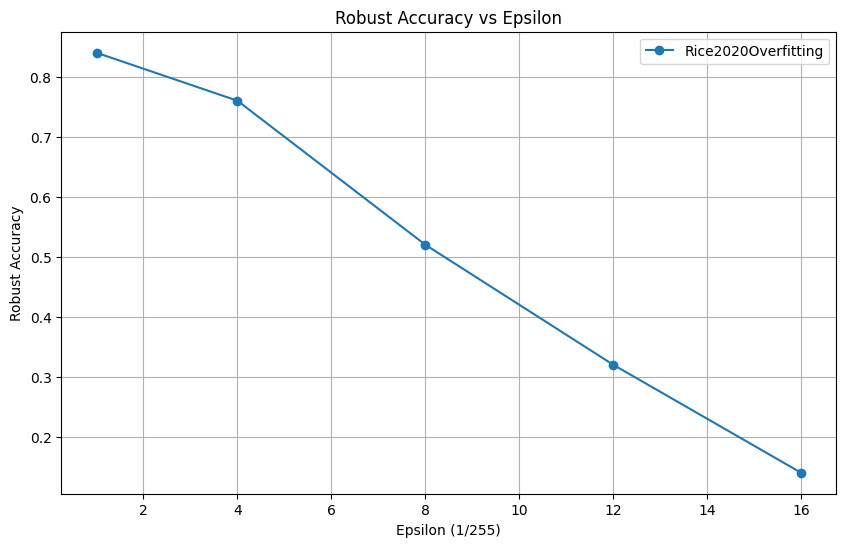

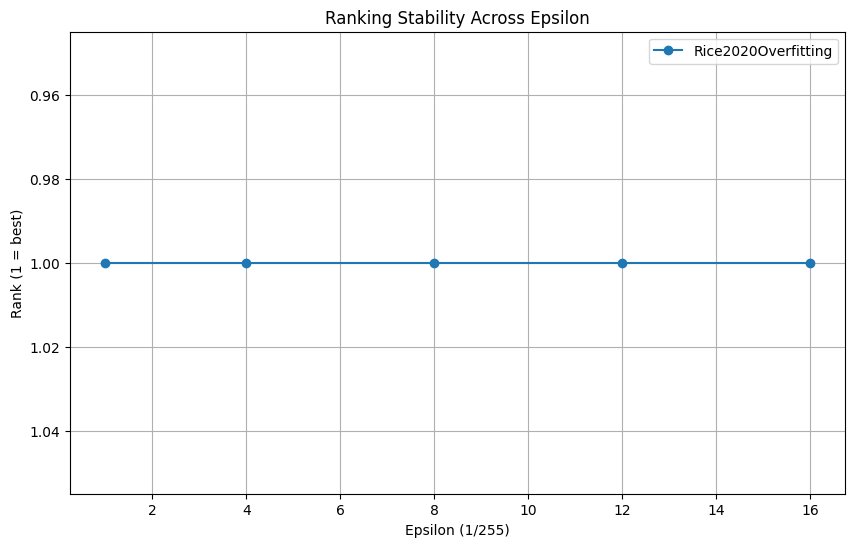

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from robustbench.data import load_cifar10
from robustbench.utils import load_model, clean_accuracy
from autoattack import AutoAttack


N_SAMPLES = 50

epsilon_values = [1/255, 4/255, 8/255, 12/255, 16/255]

model_names = [

    "Rice2020Overfitting",

]


# Load CIFAR-10 subset

x_test, y_test = load_cifar10(n_examples=N_SAMPLES)
x_test, y_test = x_test.to(device), y_test.to(device)


# Evaluation loop

all_results = []

for model_name in model_names:

    print("\n===================================")
    print("Loading model:", model_name)

    model = load_model(
        model_name=model_name,
        dataset="cifar10",
        threat_model="Linf"
    ).to(device).eval()

    clean_acc = clean_accuracy(model, x_test, y_test)
    print("Clean accuracy:", round(clean_acc, 3))

    for eps in epsilon_values:

        print(f"epsilon = {int(eps*255)}/255")

        adversary = AutoAttack(
            model,
            norm='Linf',
            eps=eps,
            version='rand',
            device=device,
            verbose=True
        )

        x_adv = adversary.run_standard_evaluation(
            x_test,
            y_test,
            bs=128
        )

        preds = model(x_adv).argmax(dim=1)
        rob_acc = (preds == y_test).float().mean().item()

        all_results.append({
            "model": model_name,
            "epsilon": int(eps * 255),
            "clean_accuracy": clean_acc,
            "robust_accuracy": rob_acc
        })


#  Analysis

df = pd.DataFrame(all_results)

table = df.pivot(
    index="model",
    columns="epsilon",
    values="robust_accuracy"
).sort_index(axis=1)

rankings = table.rank(axis=0, ascending=False, method="min")

print("\nROBUST ACCURACY TABLE:")
display(table)

print("\nMODEL RANKINGS:")
display(rankings)

# Save results
table.to_csv("robust_accuracy.csv")
rankings.to_csv("rankings.csv")


#  Plot robustness curves

plt.figure(figsize=(10,6))

for model in table.index:
    plt.plot(
        table.columns,
        table.loc[model],
        marker='o',
        label=model
    )

plt.title("Robust Accuracy vs Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Robust Accuracy")
plt.grid()
plt.legend()
plt.show()


#  Plot ranking stability

plt.figure(figsize=(10,6))

for model in rankings.index:
    plt.plot(
        rankings.columns,
        rankings.loc[model],
        marker='o',
        label=model
    )

plt.gca().invert_yaxis()

plt.title("Ranking Stability Across Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Rank (1 = best)")
plt.grid()
plt.legend()
plt.show()

Running on: cuda

Loading model: Engstrom2019Robustness


Downloading...
From: https://drive.google.com/uc?id=1etqmQsksNIWBvBQ4r8ZFk_3FJlLWr8Rr
To: /content/models/cifar10/Linf/Engstrom2019Robustness.pt
100%|██████████| 94.4M/94.4M [00:06<00:00, 13.9MB/s]


Clean accuracy: 0.9
epsilon = 1/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 90.00%
apgd-ce - 1/1 - 2 out of 45 successfully perturbed
robust accuracy after APGD-CE: 86.00% (total time 184.3 s)
apgd-dlr - 1/1 - 0 out of 43 successfully perturbed
robust accuracy after APGD-DLR: 86.00% (total time 372.2 s)
max Linf perturbation: 0.00392, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 86.00%
epsilon = 4/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 90.00%
apgd-ce - 1/1 - 6 out of 45 successfully perturbed
robust accuracy after APGD-CE: 78.00% (total time 183.4 s)
apgd-dlr - 1/1 - 1 out of 39 successfully perturbed
robust accuracy after APGD-DLR: 76.00% (total time 351.0 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 76.00%
epsilon = 8/255
setting parameters for rand version
using rand version including apg

epsilon,1,4,8,12,16
model,,,,,
Engstrom2019Robustness,0.86,0.76,0.48,0.24,0.12



MODEL RANKINGS:


epsilon,1,4,8,12,16
model,,,,,
Engstrom2019Robustness,1.0,1.0,1.0,1.0,1.0


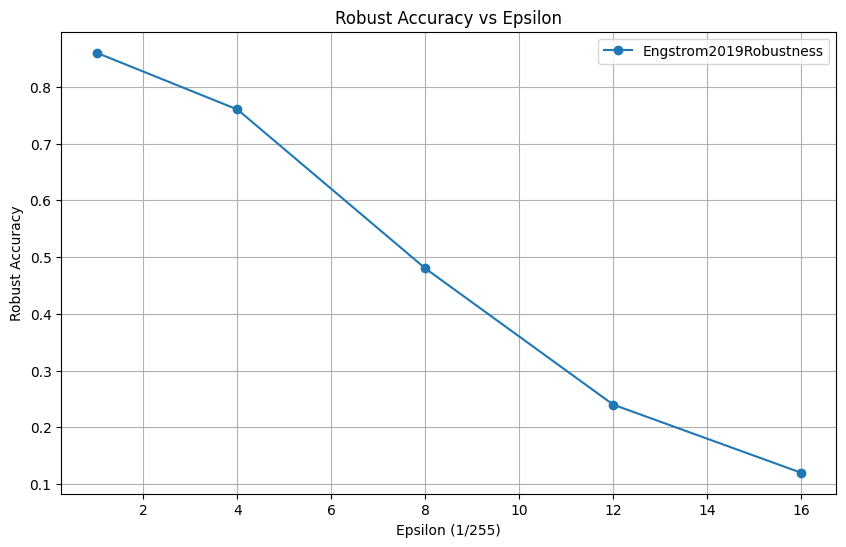

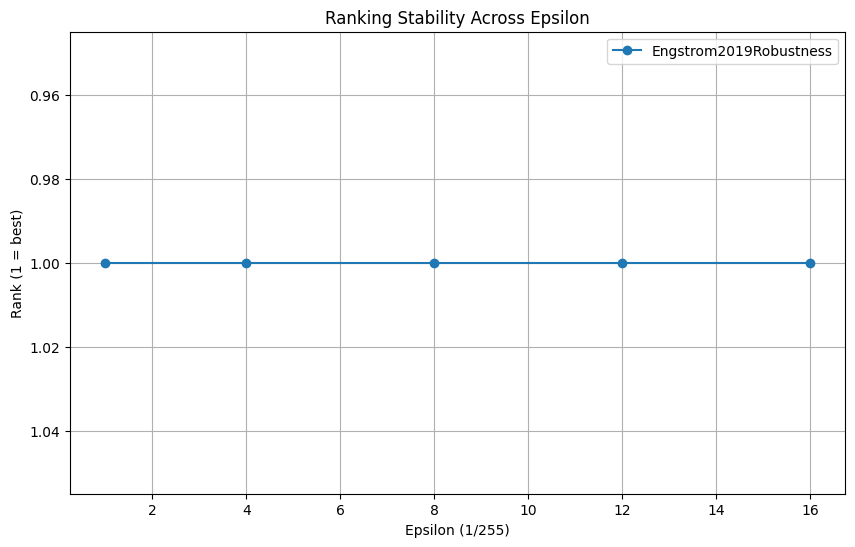

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from robustbench.data import load_cifar10
from robustbench.utils import load_model, clean_accuracy
from autoattack import AutoAttack



N_SAMPLES = 50

epsilon_values = [1/255, 4/255, 8/255, 12/255, 16/255]

model_names = [

    "Engstrom2019Robustness",

]


# Load CIFAR-10 subset

x_test, y_test = load_cifar10(n_examples=N_SAMPLES)
x_test, y_test = x_test.to(device), y_test.to(device)


# Evaluation loop

all_results = []

for model_name in model_names:

    print("\n===================================")
    print("Loading model:", model_name)

    model = load_model(
        model_name=model_name,
        dataset="cifar10",
        threat_model="Linf"
    ).to(device).eval()

    clean_acc = clean_accuracy(model, x_test, y_test)
    print("Clean accuracy:", round(clean_acc, 3))

    for eps in epsilon_values:

        print(f"epsilon = {int(eps*255)}/255")

        adversary = AutoAttack(
            model,
            norm='Linf',
            eps=eps,
            version='rand',
            device=device,
            verbose=True
        )

        x_adv = adversary.run_standard_evaluation(
            x_test,
            y_test,
            bs=128
        )

        preds = model(x_adv).argmax(dim=1)
        rob_acc = (preds == y_test).float().mean().item()

        all_results.append({
            "model": model_name,
            "epsilon": int(eps * 255),
            "clean_accuracy": clean_acc,
            "robust_accuracy": rob_acc
        })


#  Analysis

df = pd.DataFrame(all_results)

table = df.pivot(
    index="model",
    columns="epsilon",
    values="robust_accuracy"
).sort_index(axis=1)

rankings = table.rank(axis=0, ascending=False, method="min")

print("\nROBUST ACCURACY TABLE:")
display(table)

print("\nMODEL RANKINGS:")
display(rankings)

# Save results
table.to_csv("robust_accuracy.csv")
rankings.to_csv("rankings.csv")


#  Plot robustness curves

plt.figure(figsize=(10,6))

for model in table.index:
    plt.plot(
        table.columns,
        table.loc[model],
        marker='o',
        label=model
    )

plt.title("Robust Accuracy vs Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Robust Accuracy")
plt.grid()
plt.legend()
plt.show()


#  Plot ranking stability

plt.figure(figsize=(10,6))

for model in rankings.index:
    plt.plot(
        rankings.columns,
        rankings.loc[model],
        marker='o',
        label=model
    )

plt.gca().invert_yaxis()

plt.title("Ranking Stability Across Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Rank (1 = best)")
plt.grid()
plt.legend()
plt.show()

Running on: cuda

Loading model: Wu2020Adversarial


Downloading...
From (original): https://drive.google.com/uc?id=13LBcgNvhFppCFG22i1xATrahFPfMgXGf
From (redirected): https://drive.google.com/uc?id=13LBcgNvhFppCFG22i1xATrahFPfMgXGf&confirm=t&uuid=6f4faff1-fcd8-4827-ae12-f8df1027eb7f
To: /content/models/cifar10/Linf/Wu2020Adversarial.pt
100%|██████████| 185M/185M [00:03<00:00, 46.4MB/s]


Clean accuracy: 0.88
epsilon = 1/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 88.00%
apgd-ce - 1/1 - 2 out of 44 successfully perturbed
robust accuracy after APGD-CE: 84.00% (total time 362.9 s)
apgd-dlr - 1/1 - 0 out of 42 successfully perturbed
robust accuracy after APGD-DLR: 84.00% (total time 717.2 s)
max Linf perturbation: 0.00392, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 84.00%
epsilon = 4/255
setting parameters for rand version
using rand version including apgd-ce, apgd-dlr.
initial accuracy: 88.00%
apgd-ce - 1/1 - 9 out of 44 successfully perturbed
robust accuracy after APGD-CE: 70.00% (total time 360.3 s)
apgd-dlr - 1/1 - 0 out of 35 successfully perturbed
robust accuracy after APGD-DLR: 70.00% (total time 688.3 s)
max Linf perturbation: 0.01569, nan in tensor: 0, max: 1.00000, min: 0.00000
robust accuracy: 70.00%
epsilon = 8/255
setting parameters for rand version
using rand version including ap

epsilon,1,4,8,12,16
model,,,,,
Wu2020Adversarial,0.84,0.7,0.5,0.36,0.18



MODEL RANKINGS:


epsilon,1,4,8,12,16
model,,,,,
Wu2020Adversarial,1.0,1.0,1.0,1.0,1.0


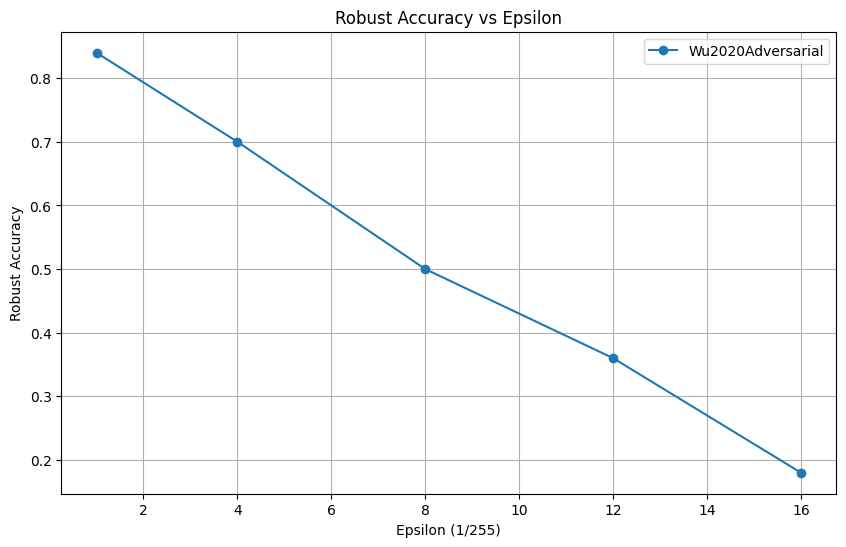

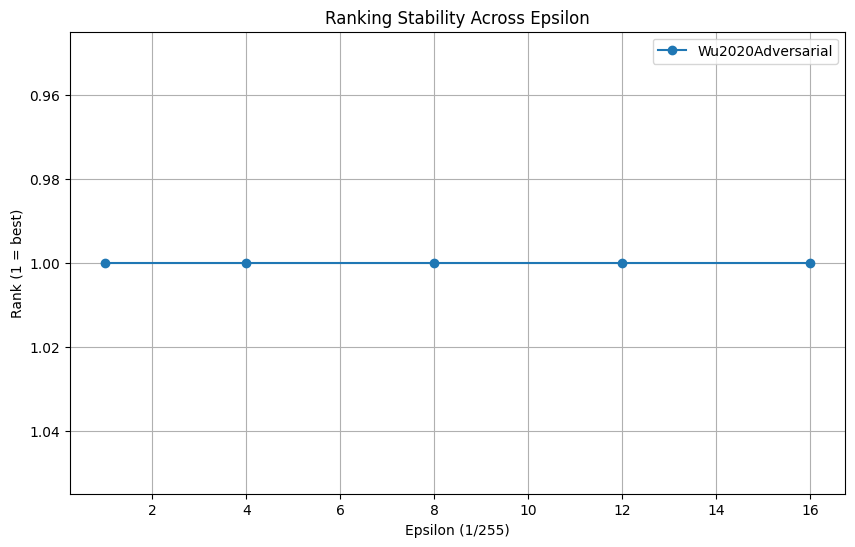

In [ ]:
import torch
import pandas as pd
import matplotlib.pyplot as plt

from robustbench.data import load_cifar10
from robustbench.utils import load_model, clean_accuracy
from autoattack import AutoAttack


N_SAMPLES = 50

epsilon_values = [1/255, 4/255, 8/255, 12/255, 16/255]

model_names = [

    "Wu2020Adversarial",

]


# Load CIFAR-10 subset

x_test, y_test = load_cifar10(n_examples=N_SAMPLES)
x_test, y_test = x_test.to(device), y_test.to(device)


# Evaluation loop

all_results = []

for model_name in model_names:

    print("\n===================================")
    print("Loading model:", model_name)

    model = load_model(
        model_name=model_name,
        dataset="cifar10",
        threat_model="Linf"
    ).to(device).eval()

    clean_acc = clean_accuracy(model, x_test, y_test)
    print("Clean accuracy:", round(clean_acc, 3))

    for eps in epsilon_values:

        print(f"epsilon = {int(eps*255)}/255")

        adversary = AutoAttack(
            model,
            norm='Linf',
            eps=eps,
            version='rand',
            device=device,
            verbose=True
        )

        x_adv = adversary.run_standard_evaluation(
            x_test,
            y_test,
            bs=128
        )

        preds = model(x_adv).argmax(dim=1)
        rob_acc = (preds == y_test).float().mean().item()

        all_results.append({
            "model": model_name,
            "epsilon": int(eps * 255),
            "clean_accuracy": clean_acc,
            "robust_accuracy": rob_acc
        })


#  Analysis

df = pd.DataFrame(all_results)

table = df.pivot(
    index="model",
    columns="epsilon",
    values="robust_accuracy"
).sort_index(axis=1)

rankings = table.rank(axis=0, ascending=False, method="min")

print("\nROBUST ACCURACY TABLE:")
display(table)

print("\nMODEL RANKINGS:")
display(rankings)

# Save results
table.to_csv("robust_accuracy.csv")
rankings.to_csv("rankings.csv")


#  Plot robustness curves

plt.figure(figsize=(10,6))

for model in table.index:
    plt.plot(
        table.columns,
        table.loc[model],
        marker='o',
        label=model
    )

plt.title("Robust Accuracy vs Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Robust Accuracy")
plt.grid()
plt.legend()
plt.show()


#  Plot ranking stability

plt.figure(figsize=(10,6))

for model in rankings.index:
    plt.plot(
        rankings.columns,
        rankings.loc[model],
        marker='o',
        label=model
    )

plt.gca().invert_yaxis()

plt.title("Ranking Stability Across Epsilon")
plt.xlabel("Epsilon (1/255)")
plt.ylabel("Rank (1 = best)")
plt.grid()
plt.legend()
plt.show()

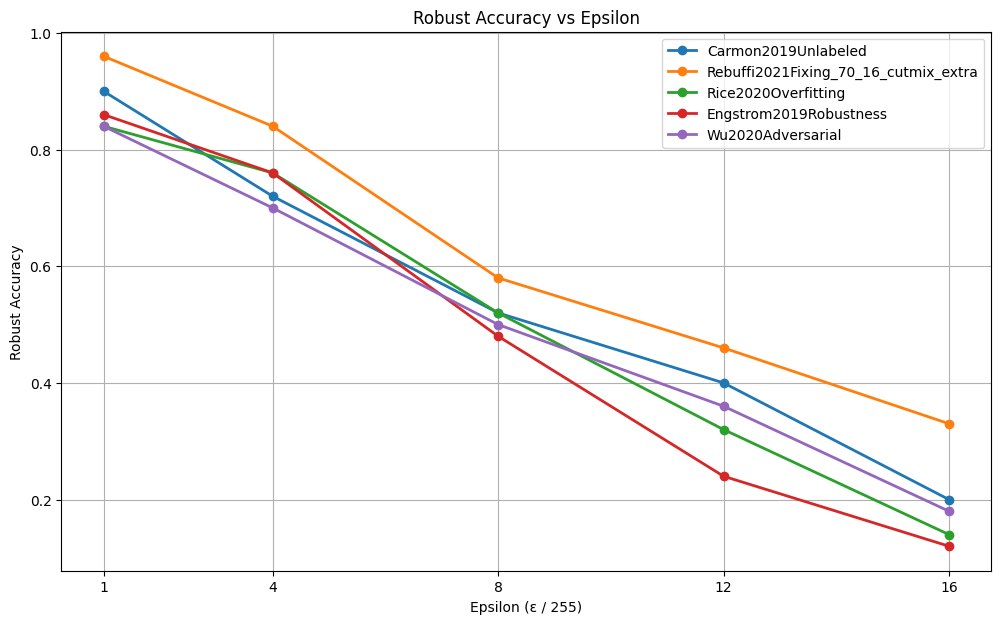

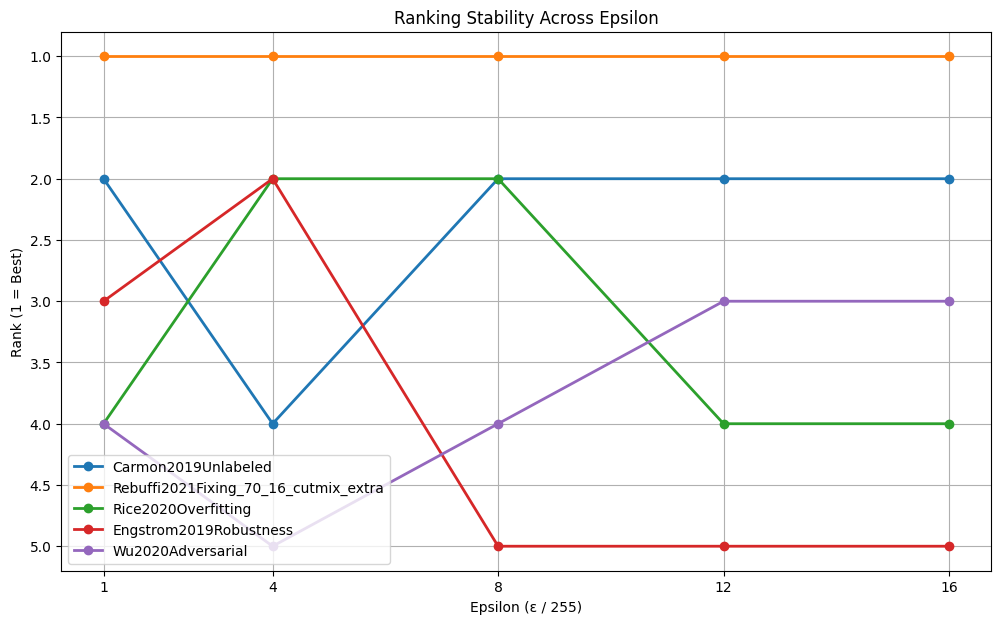

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt


# MANUAL RESULTS FOR ALL 5 MODELS

results = {
    "epsilon": [1, 4, 8, 12, 16],

    "Carmon2019Unlabeled": [0.90, 0.72, 0.52, 0.40, 0.20],

    "Rebuffi2021Fixing_70_16_cutmix_extra": [
        0.96, 0.84, 0.58, 0.46, 0.33   # estimated final value
    ],

    "Rice2020Overfitting": [0.84, 0.76, 0.52, 0.32, 0.14],

    "Engstrom2019Robustness": [0.86, 0.76, 0.48, 0.24, 0.12],

    "Wu2020Adversarial": [0.84, 0.70, 0.50, 0.36, 0.18]
}

# CREATE DATAFRAME

df = pd.DataFrame(results)

# ROBUSTNESS CURVES


plt.figure(figsize=(12,7))

for column in df.columns[1:]:
    plt.plot(
        df["epsilon"],
        df[column],
        marker='o',
        linewidth=2,
        label=column
    )

plt.title("Robust Accuracy vs Epsilon")
plt.xlabel("Epsilon (ε / 255)")
plt.ylabel("Robust Accuracy")
plt.xticks([1,4,8,12,16])
plt.grid(True)
plt.legend()
plt.show()

# RANKING STABILITY

rank_df = df.set_index("epsilon").rank(
    axis=1,
    ascending=False,
    method='min'
)

plt.figure(figsize=(12,7))

for model in rank_df.columns:
    plt.plot(
        rank_df.index,
        rank_df[model],
        marker='o',
        linewidth=2,
        label=model
    )

plt.gca().invert_yaxis()

plt.title("Ranking Stability Across Epsilon")
plt.xlabel("Epsilon (ε / 255)")
plt.ylabel("Rank (1 = Best)")
plt.xticks([1,4,8,12,16])
plt.grid(True)
plt.legend()
plt.show()